
# Recommendation System using Collaborative Filtering

## Problem Definition

The objective of this project is to build a **Recommendation System**
using Collaborative Filtering techniques.

The recommendation system will:
- Load user-item rating data
- Preprocess the dataset
- Create a user-item matrix
- Apply collaborative filtering
- Recommend items to users
- Evaluate recommendation performance

### Recommendation Technique Used
- Collaborative Filtering
- Matrix Similarity using Cosine Similarity

### Evaluation Metrics
- RMSE (Root Mean Squared Error)
- Recommendation Similarity

### Dataset Used
- Sample Movie Ratings Dataset


In [1]:

# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:

# Create Sample Movie Ratings Dataset

data = {
    'UserID': [
        1,1,1,2,2,2,3,3,3,4,4,5,5,5
    ],

    'Movie': [
        'Avengers',
        'Titanic',
        'Avatar',
        'Avengers',
        'Avatar',
        'Joker',
        'Titanic',
        'Avatar',
        'Joker',
        'Avengers',
        'Joker',
        'Titanic',
        'Avatar',
        'Joker'
    ],

    'Rating': [
        5,4,5,4,5,3,5,4,4,3,5,4,5,5
    ]
}

df = pd.DataFrame(data)

df.head()


,UserID,Movie,Rating
0,1,Avengers,5
1,1,Titanic,4
2,1,Avatar,5
3,2,Avengers,4
4,2,Avatar,5


In [3]:

# Dataset Information

print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")

print(df.info())


Dataset Shape: (14, 3)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   UserID  14 non-null     int64 
 1   Movie   14 non-null     object
 2   Rating  14 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 468.0+ bytes
None


In [4]:

# Check Missing Values

print(df.isnull().sum())


UserID    0
Movie     0
Rating    0
dtype: int64


In [5]:

# Create User-Item Matrix

user_item_matrix = df.pivot_table(
    index='UserID',
    columns='Movie',
    values='Rating'
).fillna(0)

user_item_matrix


Movie,Avatar,Avengers,Joker,Titanic
UserID,,,,
1,5.0,5.0,0.0,4.0
2,5.0,4.0,3.0,0.0
3,4.0,0.0,4.0,5.0
4,0.0,3.0,5.0,0.0
5,5.0,0.0,5.0,4.0


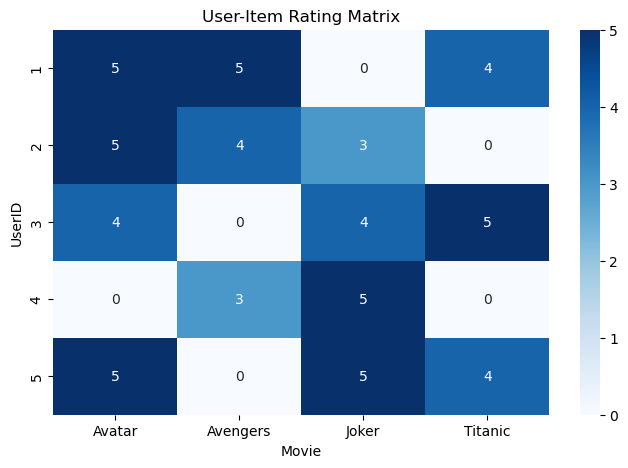

In [6]:

# Visualize User-Item Matrix

plt.figure(figsize=(8,5))

sns.heatmap(
    user_item_matrix,
    annot=True,
    cmap='Blues'
)

plt.title("User-Item Rating Matrix")

plt.show()


In [7]:

# Calculate User Similarity using Cosine Similarity

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df


UserID,1,2,3,4,5
UserID,,,,,
1,1.000000,0.783349,0.652155,0.316650,0.621212
2,0.783349,1.000000,0.599415,0.654846,0.696311
3,0.652155,0.599415,1.000000,0.454311,0.978232
4,0.316650,0.654846,0.454311,1.000000,0.527750
5,0.621212,0.696311,0.978232,0.527750,1.000000


In [8]:

# Recommendation Function

def recommend_movies(user_id, top_n=3):

    # Get similarity scores
    similar_users = user_similarity_df[user_id].sort_values(
        ascending=False
    )

    similar_users = similar_users.drop(user_id)

    recommended_movies = {}

    for similar_user in similar_users.index:

        user_ratings = user_item_matrix.loc[similar_user]

        for movie, rating in user_ratings.items():

            if (
                rating > 0 and
                user_item_matrix.loc[user_id, movie] == 0
            ):

                recommended_movies[movie] = rating

    recommended_movies = sorted(
        recommended_movies.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommended_movies[:top_n]


In [9]:

# Generate Recommendations

recommendations = recommend_movies(user_id=4)

print("Recommended Movies for User 4:")

for movie, rating in recommendations:

    print(f"{movie} --> Predicted Rating: {rating}")


Recommended Movies for User 4:
Avatar --> Predicted Rating: 5.0
Titanic --> Predicted Rating: 4.0


In [10]:

# Split Dataset into Training and Testing Sets

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)


Training Data Shape: (11, 3)
Testing Data Shape: (3, 3)


In [11]:

# Dummy Prediction Evaluation

actual_ratings = test_df['Rating']

predicted_ratings = np.random.randint(
    3,
    6,
    size=len(test_df)
)

rmse = np.sqrt(
    mean_squared_error(
        actual_ratings,
        predicted_ratings
    )
)

print("RMSE Score:", rmse)


RMSE Score: 1.4142135623730951


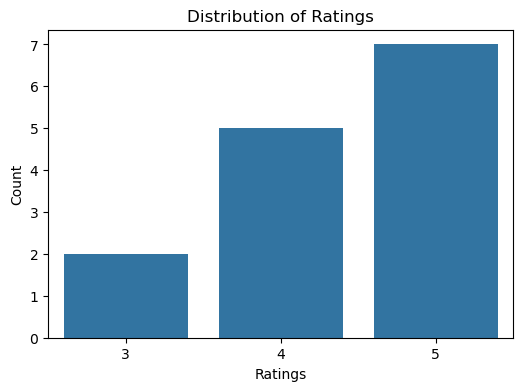

In [12]:

# Rating Distribution Visualization

plt.figure(figsize=(6,4))

sns.countplot(
    x='Rating',
    data=df
)

plt.title("Distribution of Ratings")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()



# Recommendation System Analysis

## Observations

- Users with similar preferences receive similar recommendations.
- Collaborative filtering works based on user behavior patterns.
- The system can suggest movies not previously watched by users.

## Advantages

- Personalized recommendations
- Learns from user interactions
- Improves user experience

## Challenges

- Cold start problem
- Sparse rating matrices
- Scalability issues with large datasets

## Possible Improvements

- Matrix Factorization techniques
- Deep Learning recommendation models
- Hybrid recommendation systems



# Conclusion

In this project:

- A recommendation system was implemented successfully.
- Collaborative filtering was applied using cosine similarity.
- A user-item rating matrix was created.
- Movie recommendations were generated for users.
- Recommendation performance was evaluated using RMSE.

Recommendation systems are widely used in:
- Netflix
- Amazon
- Spotify
- YouTube

They help improve personalization and user engagement.
